In [ ]:
import datetime
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import random

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input, Flatten, GRU
from keras import backend

from scipy.fft import fft, ifft, fftfreq
import pywt
import warnings
import os
import gc

import math

/tmp/ipykernel_5891/2574693381.py:46: RuntimeWarning: invalid value encountered in divide
  sinc_factor_rhs = np.sin(np.pi*np.arange(len(fxt)/2)/(len(fxt)/2))/(np.pi*np.arange(len(fxt)/2)/(len(fxt)/2))
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


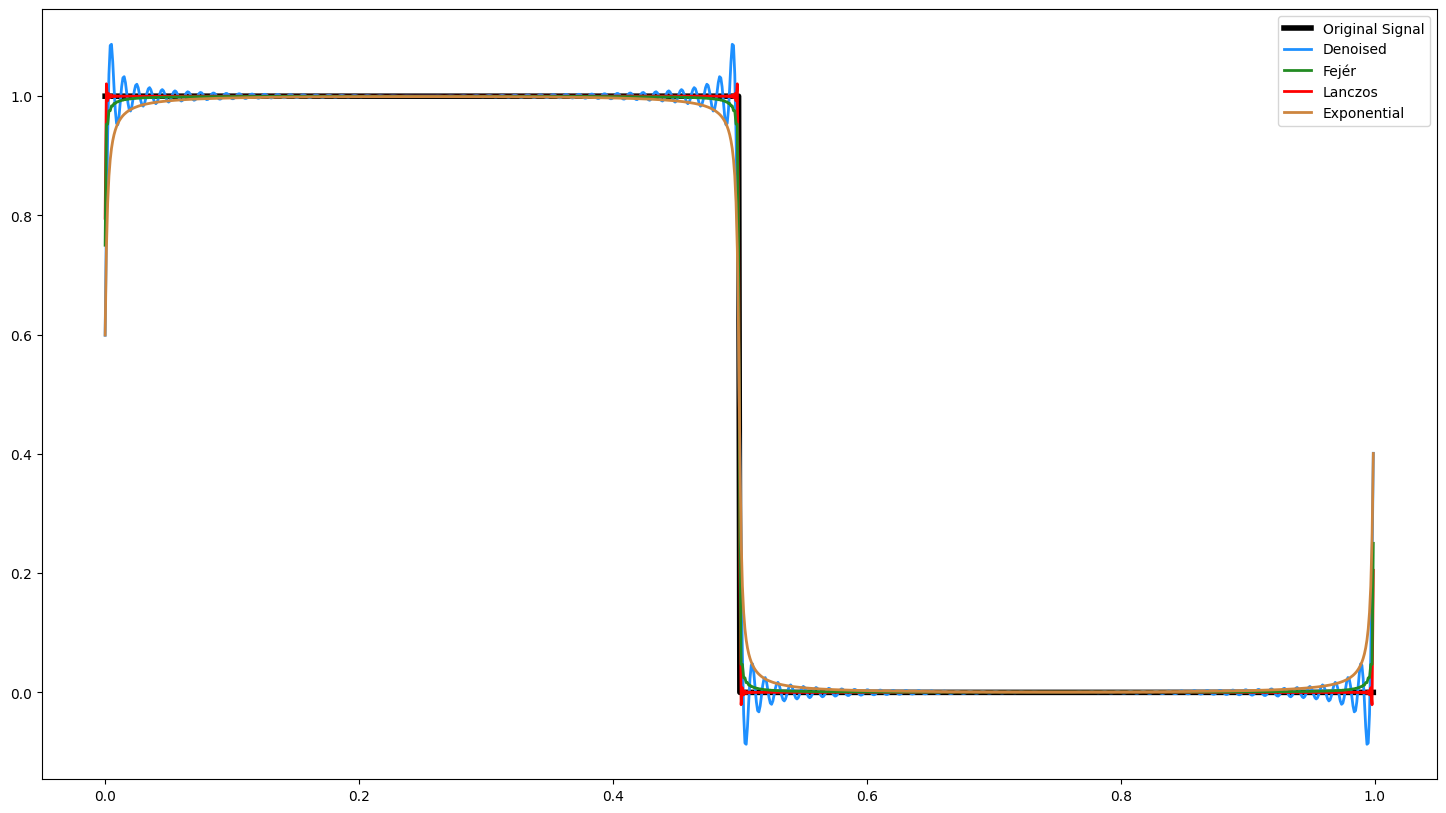

In [ ]:
n = 1000
t = np.linspace(0, 1, n, endpoint=False)
np.random.seed(42)
# signal = np.where((t < 0.25) | (t > 0.75) , 1.0, -1.0)+ np.random.normal(0,0.02,len(t))
signal = np.where(t < 0.5 , 1., 0.) #+ np.random.normal(0,0.02,len(t))

sk_df = pd.DataFrame()
Cesaro_df = pd.DataFrame()
fxt = np.fft.fft(signal)
fxt_unshifted = fxt.copy()
fxt = np.fft.fftshift(fxt)


threshold_value = np.quantile(np.abs(fxt), [0.9])

## ------ Performing threshold denoising on the data: ----------------
index = abs(fxt)> threshold_value[0] #list[i]
fxt_clean = fxt*index.T
fxt_clean = np.fft.ifftshift(fxt_clean)
signal_clean = np.fft.ifft(fxt_clean)


## ------ Performing Fejer summation on the data: ----------------
index_mtx_rhs = np.tril(np.ones((int(len(fxt)/2), int(len(fxt)/2))))
index_mtx = np.hstack((np.fliplr(index_mtx_rhs), index_mtx_rhs))
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
sk_df['PS0'] = np.zeros(len(signal))
for j in range(int(len(fxt)/2)):
  index_fej = index_mtx[j].tolist()
  fxt_singular = fxt.T * index_fej
  fxt_singular = fxt_singular.T
  fxt_singular = np.fft.ifftshift(fxt_singular)
  xt_singular = np.fft.ifft(fxt_singular)
  xt_singular = xt_singular.real.T
  sk_df['PS'+str(j+1)] = xt_singular

for j in range(int(len(fxt)/2)):
  col_list = sk_df.columns[1:j+1].tolist()
  Cesaro_df['CM'+str(j+1)] = sk_df[col_list].mean(axis=1)


## Performing Lanczos sigma-approximation on the data:

# sinc_factor = np.sin(np.pi*np.arange(len(fxt))/len(fxt))/(np.pi*np.arange(len(fxt))/len(fxt))
# sinc_factor[0] = 1
sinc_factor_rhs = np.sin(np.pi*np.arange(len(fxt)/2)/(len(fxt)/2))/(np.pi*np.arange(len(fxt)/2)/(len(fxt)/2))
sinc_factor_rhs[0] = 1
sinc_factor_rhs = sinc_factor_rhs.tolist()
sinc_factor = sinc_factor_rhs[::-1] + sinc_factor_rhs
fxt_lanczos = fxt*sinc_factor
fxt_lanczos = np.fft.ifftshift(fxt_lanczos)
signal_lanczos = np.fft.ifft(fxt_lanczos)


## Performing exponential denoising on the data:
exp_factor_rhs = 0.99**np.arange(len(fxt)/2)
exp_factor_rhs = exp_factor_rhs.tolist()
exp_factor = exp_factor_rhs[::-1] + exp_factor_rhs
fxt_exp = fxt*exp_factor
fxt_exp = np.fft.ifftshift(fxt_exp)
signal_exp = np.fft.ifft(fxt_exp)



## Plotting the figure:
plt.figure(figsize=(18,10)) #, dpi=600)
# plt.title('Signal Denoising Comparison', fontsize=14)
line1, = plt.plot(t, signal, 'k-', linewidth = 4, label = 'Original Signal')
line2, = plt.plot(t, signal_clean, color= 'dodgerblue', linestyle = '-', linewidth = 2, label = 'Denoised')
line3, = plt.plot(t, signal_lanczos, 'r-', linewidth = 2, label = 'Lanczos')
line4, = plt.plot(t, Cesaro_df.iloc[:,-1], color = 'forestgreen', linestyle = '-', linewidth = 2, label = 'Fejér')
line5, = plt.plot(t, signal_exp, color = 'peru', linestyle = '-', linewidth = 2, label = 'Exponential')
plt.legend([line1, line2, line4, line3, line5], ['Original Signal', 'Denoised', 'Fejér', 'Lanczos', 'Exponential'])
plt.show()



## Denoising Techniques:

In [ ]:
## Padding-based Fourier Transform Denoising (P-FTD), proposed by Song et al. (2021):

def padding_fourier(stock_data, quantile_percent, nr_padding_samples):
  denoised_stock_data = pd.DataFrame()

  for i in range(len(stock_data.columns)):
    xt = stock_data[stock_data.columns[i]].reset_index(drop=True)

    ## Creating the padding:
    X1_bar = np.sqrt(np.mean(xt[:20]))
    X2_bar = np.sqrt(np.mean(xt[-20:]))

    sigma1 = np.sqrt(np.mean(xt[:20]-X1_bar))
    sigma2 = np.sqrt(np.mean(xt[-20:]-X2_bar))

    np.random.seed(i)
    N1_list = np.random.normal(loc=0, scale=sigma1, size=nr_padding_samples)
    N2_list = np.random.normal(loc=0, scale=sigma2, size=nr_padding_samples)

    lower_pad_series = pd.Series(np.flip(N1_list.cumsum())+xt.iloc[0])
    upper_pad_series = pd.Series(N1_list.cumsum()+xt.iloc[-1])

    xt = pd.concat([lower_pad_series, xt, upper_pad_series], ignore_index=True)

    fxt = np.fft.fftn(xt)

    fxt = np.fft.fftshift(fxt)

    quantile_percent_index = int(len(fxt)*(1-quantile_percent))
    one_percent_index = int(len(fxt)*0.01)

    if stock_data.columns[i] == 'Volume':
      threshold_value = one_percent_index
    else:
      threshold_value = quantile_percent_index

    fxt_clean = fxt.copy()
    fxt_clean[:int(len(fxt_clean)/2)-threshold_value] = [0]*(int(len(fxt_clean)/2) - threshold_value)
    fxt_clean[int(len(fxt_clean)/2)+threshold_value:] = [0]*(len(fxt) - int(len(fxt_clean)/2) - threshold_value)

    # print(fxt_clean)
    # plt.plot(fxt)
    # plt.plot(fxt_clean)
    # plt.show()

    fxt_clean = np.fft.ifftshift(fxt_clean)
    xt_clean = np.fft.ifftn(fxt_clean)

    xt_unpadded = xt_clean[nr_padding_samples:-nr_padding_samples]
    denoised_stock_data[stock_data.columns[i]] = xt_unpadded.real

  denoised_stock_data.index = stock_data.index
  return denoised_stock_data

In [ ]:
## Our proposed Linear Drift Denoising (LDD) method:

def linear_drift_denoising(stock_data, quantile_percent):
  denoised_stock_data = pd.DataFrame()

  date_range = np.linspace(0,len(stock_data)-1,len(stock_data))
  for i in range(len(stock_data.columns)):
    xt = stock_data[stock_data.columns[i]]
    lin_drift_slope = (xt.iloc[-1] - xt.iloc[0])/len(xt)
    lin_drift = []
    for j in date_range:
      lin_drift.append(float(xt.iloc[0] + lin_drift_slope * j))
    xt_undrifted = xt - lin_drift
    fxt = np.fft.fft(xt_undrifted)
    if stock_data.columns[i] == 'Volume':
      threshold_value = np.quantile(np.abs(fxt), [0.99])
    else:
      threshold_value = np.quantile(np.abs(fxt), [quantile_percent])
    index = abs(fxt)> threshold_value[0]
    fxt_clean = fxt*index
    xt_clean = np.fft.ifft(fxt_clean)
    xt_clean = xt_clean.real
    xt_clean_redrifted = xt_clean + lin_drift

    denoised_stock_data[stock_data.columns[i]] = xt_clean_redrifted

  denoised_stock_data.index = stock_data.index
  return denoised_stock_data

In [ ]:
## Our proposed Exponential Linear Drift Denoising (Exp-LDD) method:

def lindrift_exponential_denoising(stock_data, exponential_decay_rate):
  denoised_stock_data = pd.DataFrame()

  date_range = np.linspace(0,len(stock_data)-1,len(stock_data))
  for i in range(len(stock_data.columns)):
    xt = stock_data[stock_data.columns[i]]
    lin_drift_slope = (xt.iloc[-1] - xt.iloc[0])/len(xt)
    lin_drift = []
    for j in date_range:
      lin_drift.append(float(xt.iloc[0] + lin_drift_slope * j))
    xt_undrifted = xt - lin_drift
    fxt = np.fft.fft(xt_undrifted)
    fxt_unshifted = fxt.copy()
    fxt = np.fft.fftshift(fxt)
    if stock_data.columns[i]=='Volume':
      exponential_decay_rate_used = 0.8
    else:
      exponential_decay_rate_used = exponential_decay_rate
    exponential_decay_factor = exponential_decay_rate_used**np.abs(np.arange(len(fxt)) - math.floor(len(fxt)/2))
    fxt_clean = fxt*exponential_decay_factor
    fxt_clean = np.fft.ifftshift(fxt_clean)

    # plt.plot(fxt_unshifted)
    # plt.plot(fxt_clean)
    # plt.show()

    xt_clean = np.fft.ifft(fxt_clean)
    xt_clean = xt_clean.real
    xt_clean_redrifted = xt_clean + lin_drift

    denoised_stock_data[stock_data.columns[i]] = xt_clean_redrifted

  denoised_stock_data.index = stock_data.index
  return denoised_stock_data

In [ ]:
## Our proposed Exponential Variable Denoising (Exp-VD) method:

def exponential_variable_denoising(stock_data, quantile_percent, min_max_range, smoothing_range, exponential_decay_rate):
  ## -------------- Creating the variable Min-Max range: ----------------------
  min_val = stock_data.head(min_max_range).min().tolist()
  max_val = stock_data.head(min_max_range).max().tolist()

  min_list_vals = [min_val[:] for _ in range(min_max_range)]
  max_list_vals = [max_val[:] for _ in range(min_max_range)]

  # test_len

  for i in range(len(stock_data)-min_max_range):
    min_val = stock_data.iloc[i:i+min_max_range,:].min().tolist()
    max_val = stock_data.iloc[i:i+min_max_range,:].max().tolist()
    min_list_vals.append(min_val)
    max_list_vals.append(max_val)

  # min_list = pd.DataFrame()
  # max_list = pd.DataFrame()

  min_list = pd.DataFrame(min_list_vals, columns = stock_data.columns.tolist())
  max_list = pd.DataFrame(max_list_vals, columns = stock_data.columns.tolist())

  min_list.index = stock_data.index
  max_list.index = stock_data.index

  ## Setting fixed scaling range for Volume to improve consistency:
  min_list['Volume'] = stock_data['Volume'].min()
  max_list['Volume'] = stock_data['Volume'].max()

  avg_list = (min_list+max_list)/2

  data_scaled = (stock_data - avg_list)/(max_list - min_list)

  ## -------- Smoothing the minmax scaling: --------------
  min_list_smoothed = min_list.iloc[:smoothing_range,:].values.tolist()
  max_list_smoothed = max_list.iloc[:smoothing_range,:].values.tolist()

  for i in range(len(min_list)-int(2*smoothing_range)):
    min_vals_smoothed = min_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    min_list_smoothed.append(min_vals_smoothed)

    max_vals_smoothed = max_list.iloc[i:i+int(2*smoothing_range),:].mean().values.tolist()
    max_list_smoothed.append(max_vals_smoothed)

  end_vals_min = min_list.iloc[-smoothing_range:,:].values.tolist()
  min_list_smoothed = min_list_smoothed + end_vals_min

  end_vals_max = max_list.iloc[-smoothing_range:,:].values.tolist()
  max_list_smoothed = max_list_smoothed + end_vals_max

  min_list_smoothed = pd.DataFrame(min_list_smoothed, columns = stock_data.columns.tolist())
  min_list_smoothed.index = min_list.index
  min_list_smoothed

  max_list_smoothed = pd.DataFrame(max_list_smoothed, columns = stock_data.columns.tolist())
  max_list_smoothed.index = max_list.index
  max_list_smoothed

  avg_list_smoothed = (min_list_smoothed+max_list_smoothed)/2

  ## FFT denoising of smoothed curve:
  denoised_stock_data_variable = pd.DataFrame()
  for i in range(len(data_scaled.columns)):
    ## Creating the FFT smoothed curve:
    xt = data_scaled[data_scaled.columns[i]]
    fxt = np.fft.fftn(xt)
    fxt_unshifted = fxt.copy()

    fxt = np.fft.fftshift(fxt)
    # exponential_decay_factor = exponential_decay_rate**np.abs(np.arange(len(fxt)) - len(fxt)/2)
    exponential_decay_factor = exponential_decay_rate**np.abs(np.arange(len(fxt)) - math.floor(len(fxt)/2))
    fxt_clean = fxt*exponential_decay_factor
    fxt_clean = np.fft.ifftshift(fxt_clean)
    xt_clean = np.fft.ifftn(fxt_clean)

    # plt.plot(fxt_unshifted)
    # plt.plot(fxt_clean)
    # plt.show()

    xt_clean = xt_clean.real
    denoised_stock_data_variable[data_scaled.columns[i]] = xt_clean

  denoised_stock_data_variable.index = stock_data.index
  # for i in range(len(data_scaled.columns)):
  #   plt.figure()
  #   plt.plot(data_scaled[data_scaled.columns[i]], 'b-')
  #   plt.plot(denoised_stock_data_variable[data_scaled.columns[i]], 'r-')
  #   plt.title(data_scaled.columns[i])
  #   plt.show()

  ## ------------- Rescaling using the smoothed Min-Max scaling: ----------------

  # denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list - min_list) + avg_list
  denoised_stock_data_rescaled = denoised_stock_data_variable*(max_list_smoothed - min_list_smoothed) + avg_list_smoothed

  return denoised_stock_data_rescaled

In [ ]:
def fourier_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent):
  test_len = 30
  memory = 20

  stock = yf.Ticker(stock_symbol)
  hist = stock.history(start=start_date, end=end_date, interval='1d')
  # hist.to_csv(f'{stock_symbol}_{start_date}_{end_date}.csv')
  stock_data = hist[cols_list]

  if denoising_method == 'None':
    denoised_stock_data = stock_data
  elif denoising_method == 'P-FTD':
    nr_padding_samples = 20
    denoised_stock_data = padding_fourier(stock_data.iloc[:-test_len], quantile_percent, nr_padding_samples)
    # denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])
  elif denoising_method == 'LDD':
    denoised_stock_data = linear_drift_denoising(stock_data.iloc[:-test_len], quantile_percent)
    # denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])
  elif denoising_method == 'Exp-LDD':
    exponential_decay_rate = 0.95
    denoised_stock_data = lindrift_exponential_denoising(stock_data[:-test_len], exponential_decay_rate)
    # denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])
  elif denoising_method == 'Exp-VD':
    min_max_range = 5
    smoothing_range = 5
    exponential_decay_rate = 0.8
    denoised_stock_data = exponential_variable_denoising(stock_data[:-test_len], quantile_percent, min_max_range, smoothing_range, exponential_decay_rate)
    # denoised_stock_data = pd.concat([denoised_stock_data, stock_data.iloc[-test_len:]])


  return denoised_stock_data

In [ ]:
def fourier_denoised_plotter(stock_symbol, start_date, end_date, cols_list, denoising_method_list, quantile_percent, color_list):
  test_len = 30
  memory = 20

  stock = yf.Ticker(stock_symbol)
  hist = stock.history(start=start_date, end=end_date, interval='1d')
  # hist.to_csv(f'{stock_symbol}_{start_date}_{end_date}.csv')
  stock_data = hist[cols_list]

  plt.figure(figsize=(16,int(6*len(cols_list)))) #, dpi = 600)
  color_nr = -1
  for denoising_method in denoising_method_list:
    denoised_stock_data = fourier_processor(stock_symbol, start_date, end_date, cols_list, denoising_method, quantile_percent)
    color_nr = color_nr+1

    i = 0
    if denoising_method != 'None':
      for col in cols_list:
        i = i+1
        plt.subplot(len(stock_data.columns), 1, i)
        if denoising_method == denoising_method_list[0]:
          plt.plot(stock_data[col].iloc[:-test_len], 'b-', linewidth = 1, label = 'Raw')
        # else:
        #   plt.plot(stock_data[col].iloc[:-test_len], 'b-')
        plt.plot(denoised_stock_data[col], color = color_list[color_nr], linestyle = '-', label = denoising_method) #color = 'firebrick',
        plt.xlabel('Date')
        plt.ylabel(col)
        if len(denoising_method_list) > 1:
          plt.title(f'{stock_symbol} {col} (Denoising Comparison)', fontsize=14)
        else:
          plt.title(f'{stock_symbol} {col} ({denoising_method})', fontsize=14)
        plt.legend()
  plt.show()

## Plotting the Denoising methods:

For illustration, we use the S&P/TSX Composite Index ETF (^GSPTSE) daily closing price and trading volume between January 2024 and January 2026.

In [ ]:
stock_symbol = '^GSPTSE'
start_date = '2024-01-01'
end_date = '2026-01-01'
cols_list = ['Close', 'Volume'] #['Open', 'High', 'Low', 'Close', 'Volume']
quantile_percent = 0.95
plot_yes_no = 'Yes'

color_list = ['firebrick', 'darkorange', 'mediumorchid', 'limegreen']

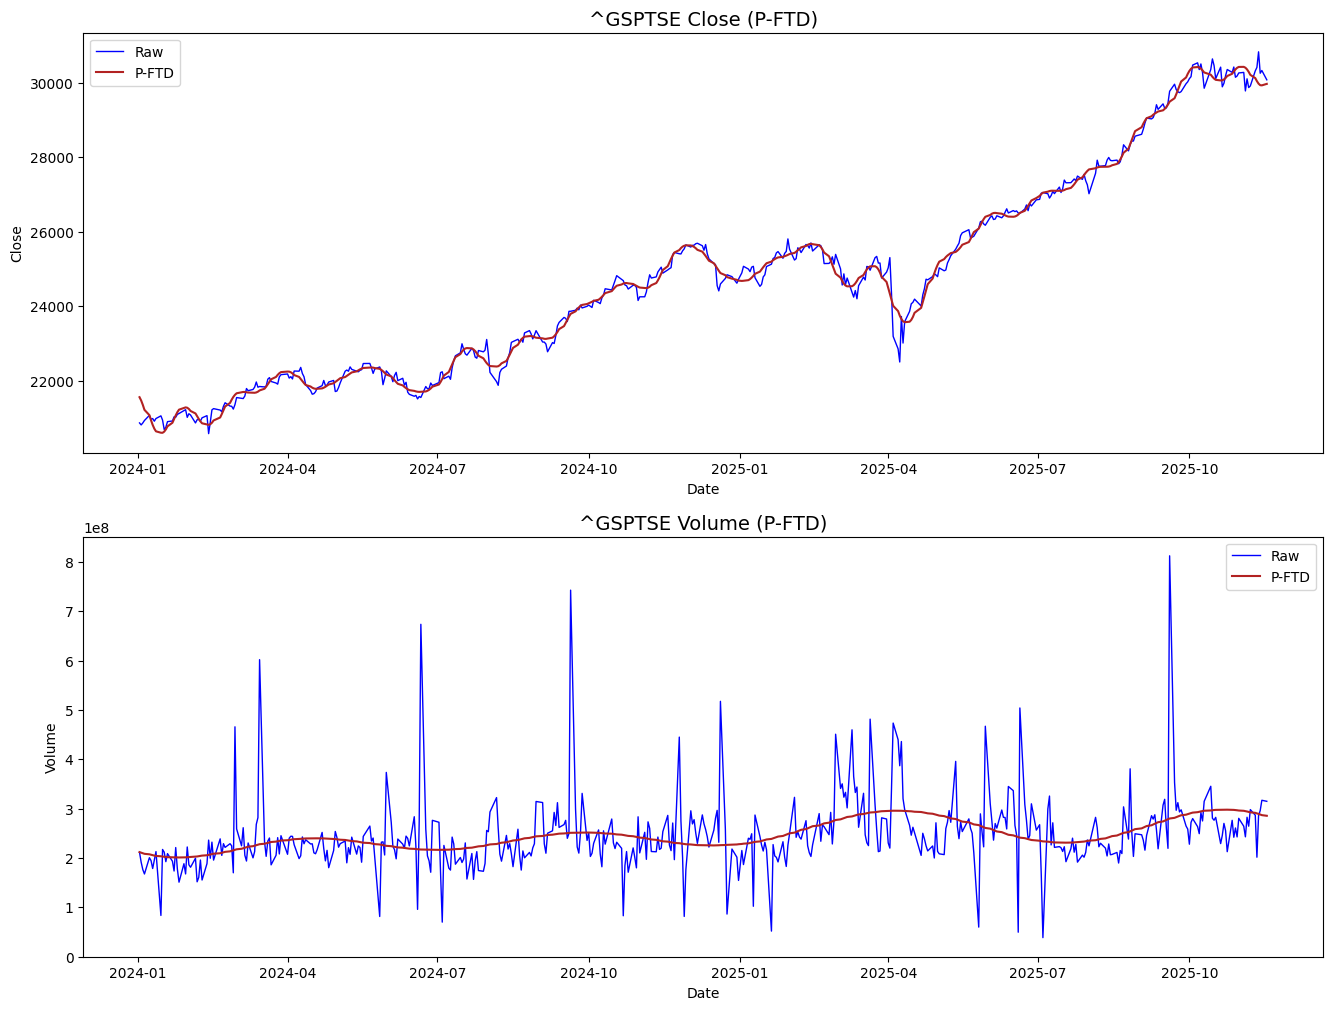

In [ ]:
## Plotting the Padding-based Fourier Transform Denoising (P-FTD) method proposed by Song et al. (2021):

denoising_method_list = ['P-FTD']
fourier_denoised_plotter(stock_symbol, start_date, end_date, cols_list, denoising_method_list, quantile_percent, color_list)

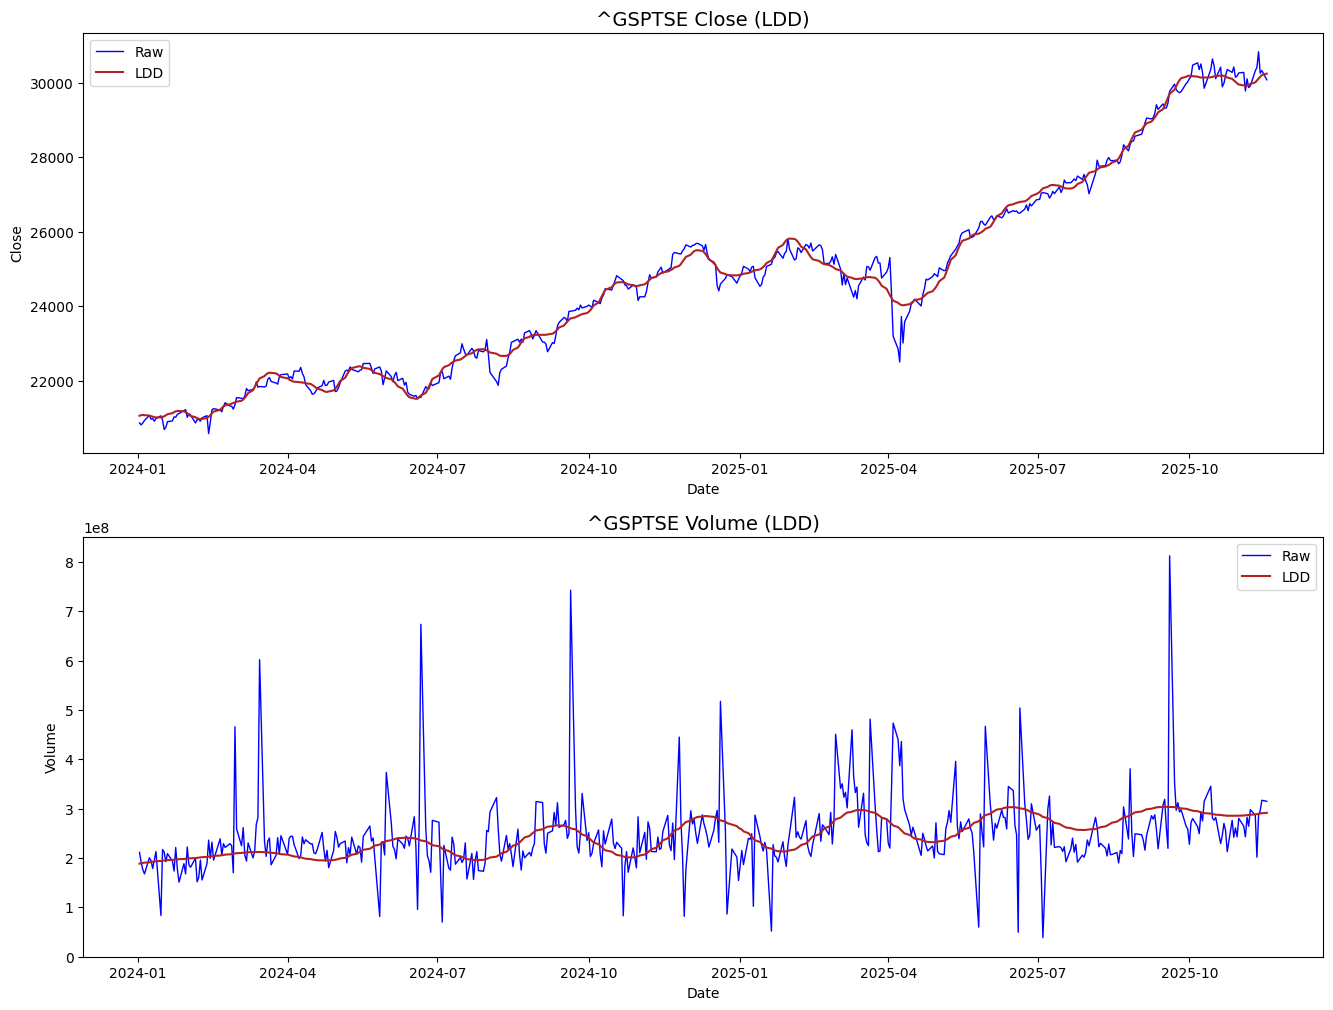

In [ ]:
## Plotting our proposed Linear Drift Denoising (LDD) method:

denoising_method_list = ['LDD']
fourier_denoised_plotter(stock_symbol, start_date, end_date, cols_list, denoising_method_list, quantile_percent, color_list)

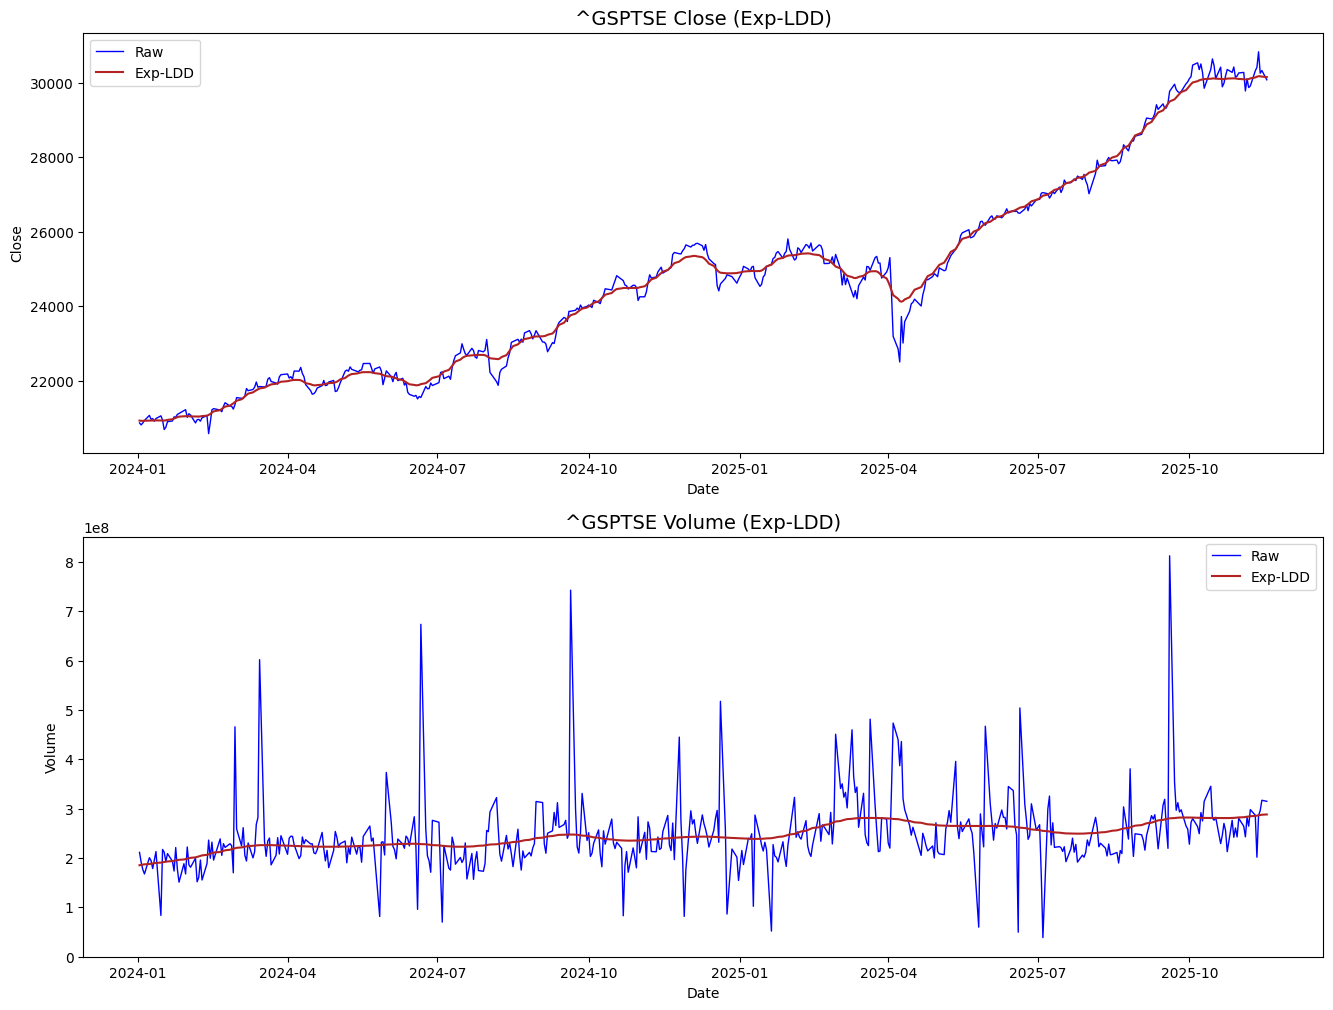

In [ ]:
## Plotting our proposed Exponential Linear Drift Denoising (Exp-LDD) method:

denoising_method_list = ['Exp-LDD']
fourier_denoised_plotter(stock_symbol, start_date, end_date, cols_list, denoising_method_list, quantile_percent, color_list)

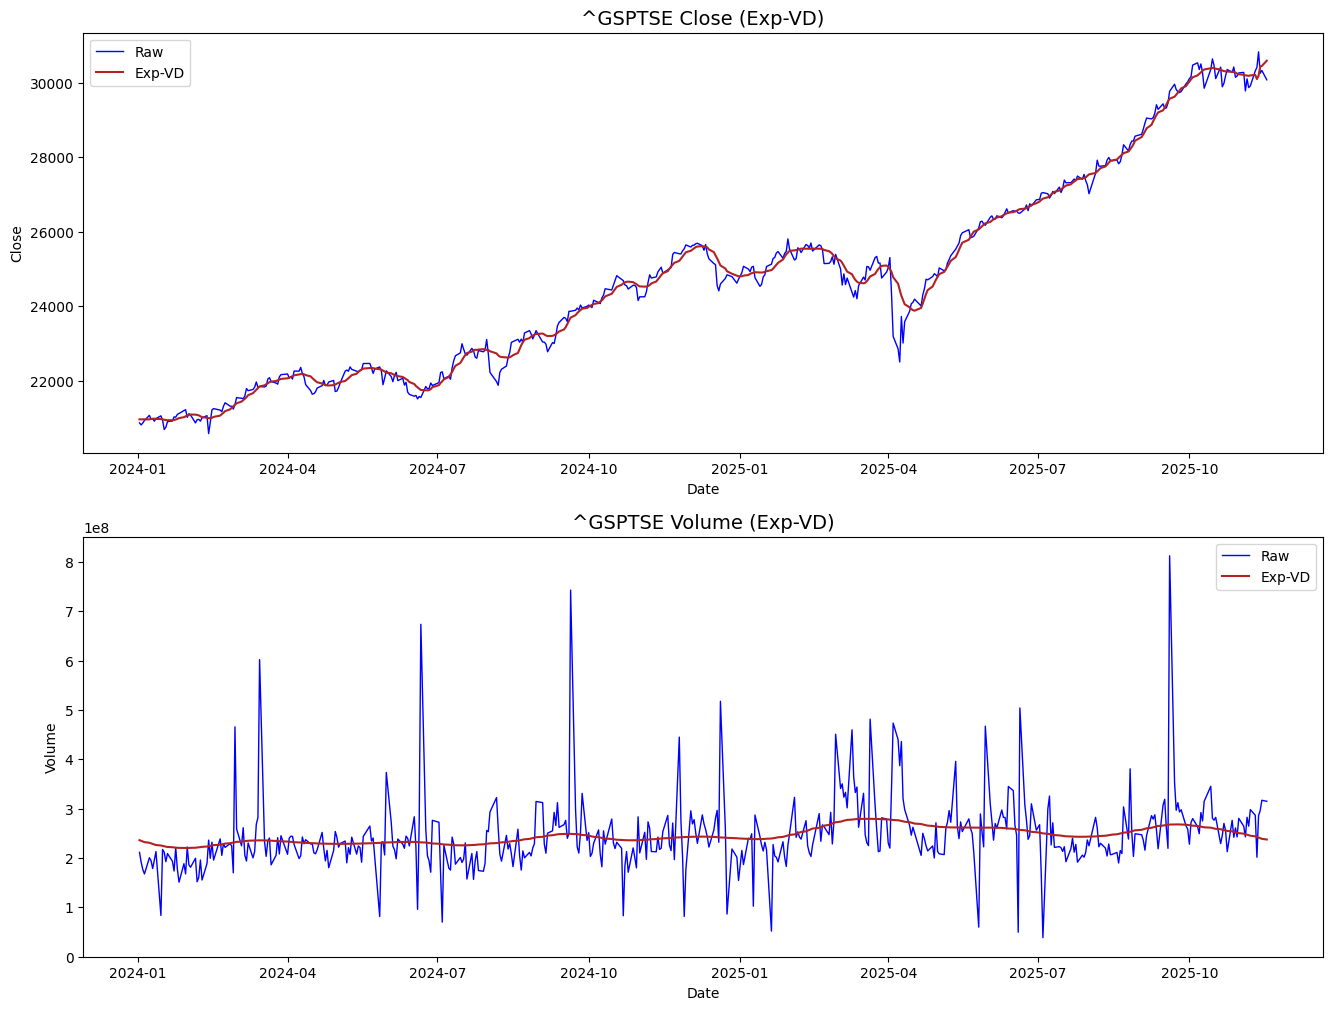

In [ ]:
## Plotting our proposed Exponential Variable Denoising (Exp-VD) method:

denoising_method_list = ['Exp-VD']
fourier_denoised_plotter(stock_symbol, start_date, end_date, cols_list, denoising_method_list, quantile_percent, color_list)

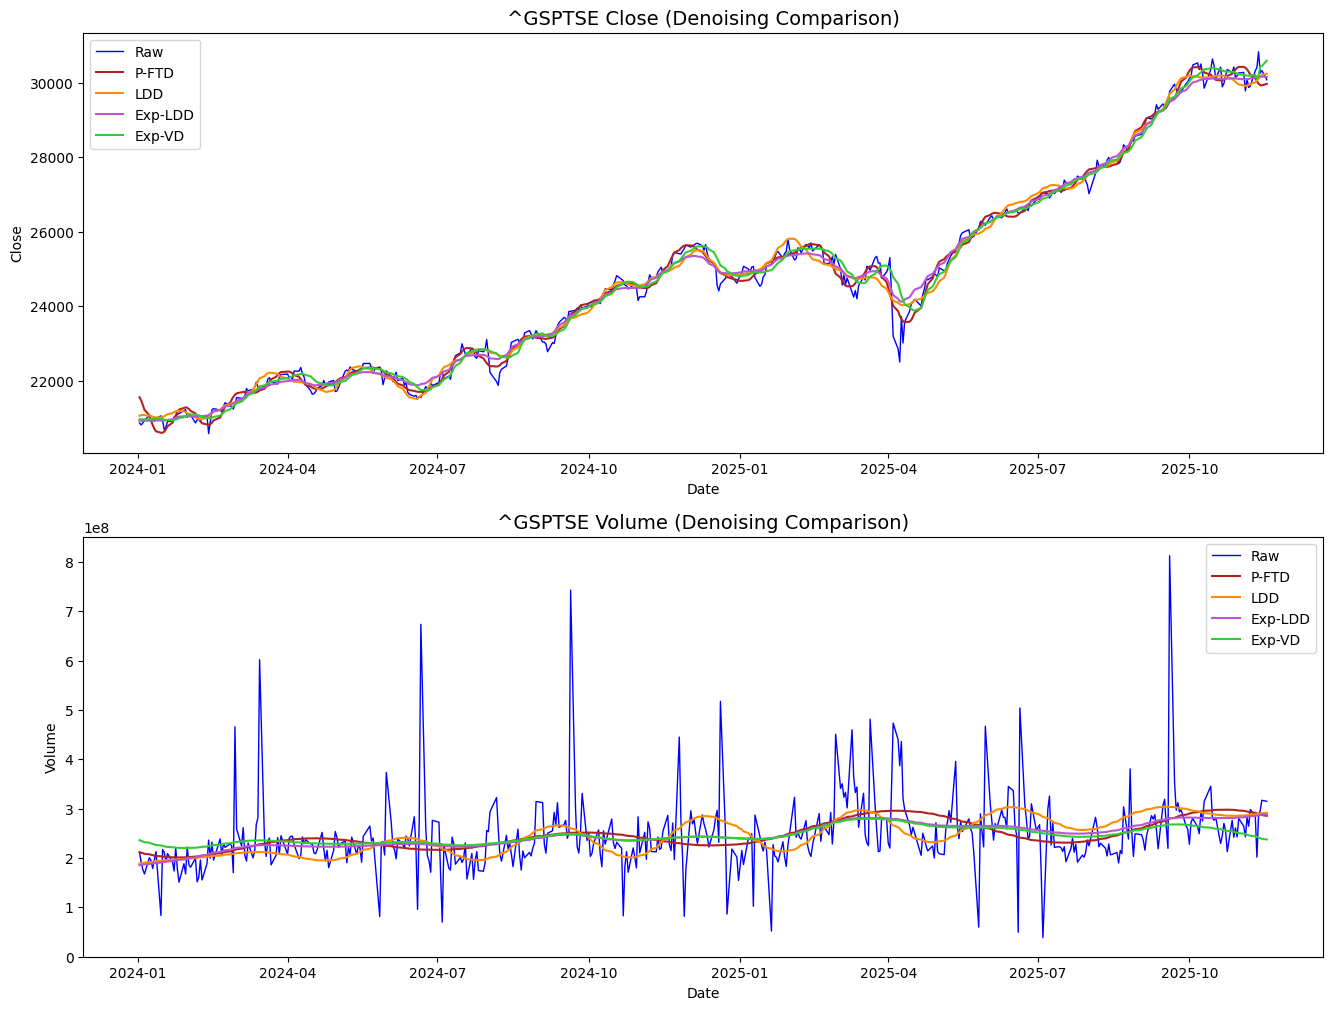

In [ ]:
## Plotting all the denoising methods together:

denoising_method_list = ['P-FTD', 'LDD', 'Exp-LDD', 'Exp-VD']
fourier_denoised_plotter(stock_symbol, start_date, end_date, cols_list, denoising_method_list, quantile_percent, color_list)